<a href="https://colab.research.google.com/github/mazzarrella0/AI---Mod-1/blob/main/AI_Mod_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import semua library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("train.csv")

print(df.shape)
df.head()



# Supaya grafik tampil di notebook
%matplotlib inline

print("Library berhasil di-import! ✅")

SyntaxError: invalid syntax (279055172.py, line 7)

In [ ]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID_Pelanggan          700 non-null    int64  
 1   Gender                700 non-null    object 
 2   Lansia                700 non-null    int64  
 3   Memiliki_Pasangan     700 non-null    object 
 4   Tanggungan            700 non-null    object 
 5   Lama_Berlangganan     492 non-null    float64
 6   Layanan_Internet      562 non-null    object 
 7   Keamanan_Online       700 non-null    object 
 8   Dukungan_Teknis       700 non-null    object 
 9   Jenis_Kontrak         557 non-null    object 
 10  Metode_Pembayaran     700 non-null    object 
 11  Biaya_Bulanan         486 non-null    float64
 12  Jumlah_Layanan        700 non-null    int64  
 13  Kompleksitas_Layanan  700 non-null    float64
 14  Total_Biaya           700 non-null    float64
dtypes: float64(4), int64(3)

In [ ]:
# Load dataset
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

print("Shape train:", train.shape)
print("Shape test:", test.shape)
print("\nPreview train:")
train.head()

Shape train: (700, 15)
Shape test: (300, 14)

Preview train:


,ID_Pelanggan,Gender,Lansia,Memiliki_Pasangan,Tanggungan,Lama_Berlangganan,Layanan_Internet,Keamanan_Online,Dukungan_Teknis,Jenis_Kontrak,Metode_Pembayaran,Biaya_Bulanan,Jumlah_Layanan,Kompleksitas_Layanan,Total_Biaya
0,542,Perempuan,0,Ya,Ya,52.0,NaN,Tidak internet service,Tidak internet service,NaN,Bank transfer (automatic),2.505,0,0.0,39.08
1,441,Laki-laki,0,Ya,Ya,71.0,DSL,Ya,Ya,Dua tahun,Mailed check,NaN,6,547.5,194.36
2,483,Laki-laki,1,Tidak,Tidak,55.0,Fiber optic,Ya,Tidak,Perbulan,Electronic check,9.880,3,296.4,163.02
3,423,Perempuan,0,Ya,Ya,NaN,Tidak,Tidak internet service,Tidak internet service,Satu tahun,Bank transfer (automatic),NaN,0,0.0,40.10
4,779,Laki-laki,0,Tidak,Tidak,1.0,Tidak,Tidak internet service,Tidak internet service,Perbulan,Mailed check,2.060,0,0.0,0.62




---



In [ ]:
# handle missing
df = df.fillna(df.median(numeric_only=True))

# encoding categorical
df = pd.get_dummies(df, drop_first=True)

# FEATURE ENGINEERING
for col in df.select_dtypes(include=np.number).columns:
    if col != 'Total_Biaya':
        df[f'{col}_squared'] = df[col] ** 2

print("Preprocessing selesai")

Preprocessing selesai


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Total_Biaya', axis=1)
y = df['Total_Biaya']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Split Data selesai")

Split Data selesai


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling selesai")

Scaling selesai


In [ ]:
def mape_safe(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

print("MAPE selesai")

MAPE selesai




---



##- Persiapan

###Eksplorasi awal (info, statistik, missing values)

In [ ]:
print("=== INFO DATASET ===")
train.info()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID_Pelanggan          700 non-null    int64  
 1   Gender                700 non-null    object 
 2   Lansia                700 non-null    int64  
 3   Memiliki_Pasangan     700 non-null    object 
 4   Tanggungan            700 non-null    object 
 5   Lama_Berlangganan     492 non-null    float64
 6   Layanan_Internet      562 non-null    object 
 7   Keamanan_Online       700 non-null    object 
 8   Dukungan_Teknis       700 non-null    object 
 9   Jenis_Kontrak         557 non-null    object 
 10  Metode_Pembayaran     700 non-null    object 
 11  Biaya_Bulanan         486 non-null    float64
 12  Jumlah_Layanan        700 non-null    int64  
 13  Kompleksitas_Layanan  700 non-null    float64
 14  Total_Biaya           700 non-null    float64
dtypes:

In [ ]:
print("=== STATISTIK DASAR ===")
train.describe()

=== STATISTIK DASAR ===


,ID_Pelanggan,Lansia,Lama_Berlangganan,Biaya_Bulanan,Jumlah_Layanan,Kompleksitas_Layanan,Total_Biaya
count,700.000000,700.000000,492.000000,486.000000,700.000000,700.000000,700.000000
mean,500.821429,0.152857,31.430894,6.386481,1.940000,159.926500,62.743529
std,287.205506,0.360107,24.796387,2.898794,1.771447,166.866118,64.215758
min,1.000000,0.000000,1.000000,1.880000,0.000000,0.000000,0.580000
25%,245.500000,0.000000,7.000000,4.078750,0.000000,0.000000,10.670000
50%,500.000000,0.000000,28.000000,7.002500,2.000000,111.900000,38.325000
75%,749.500000,0.000000,54.000000,8.666250,3.000000,279.487500,101.877500
max,1000.000000,1.000000,72.000000,11.750000,6.000000,705.000000,253.800000


In [ ]:
print("=== MISSING VALUES ===")
print(train.isnull().sum())

=== MISSING VALUES ===
ID_Pelanggan              0
Gender                    0
Lansia                    0
Memiliki_Pasangan         0
Tanggungan                0
Lama_Berlangganan       208
Layanan_Internet        138
Keamanan_Online           0
Dukungan_Teknis           0
Jenis_Kontrak           143
Metode_Pembayaran         0
Biaya_Bulanan           214
Jumlah_Layanan            0
Kompleksitas_Layanan      0
Total_Biaya               0
dtype: int64


## Soal 1: Eksplorasi dan Preprocessing Data

### Identifikasi Tipe Data
Dataset memiliki 15 kolom dengan rincian:
- **Numerik**: Lama_Berlangganan, Biaya_Bulanan, Jumlah_Layanan, Kompleksitas_Layanan, Lansia
- **Kategorikal**: Gender, Memiliki_Pasangan, Tanggungan, Layanan_Internet, Keamanan_Online, Dukungan_Teknis, Jenis_Kontrak, Metode_Pembayaran
- **Target**: Total_Biaya (numerik kontinu)

### Missing Values yang Ditemukan
Terdapat missing values pada 4 kolom yang perlu ditangani sebelum modeling:
- `Lama_Berlangganan` dan `Biaya_Bulanan` (numerik) → diisi dengan **median**
- `Layanan_Internet` dan `Jenis_Kontrak` (kategorikal) → diisi dengan **modus**

### Alasan Pemilihan Metode
Median dipilih untuk numerik karena lebih robust terhadap outlier dibanding mean, mengingat distribusi Total_Biaya bersifat right-skewed. Modus dipilih untuk kategorikal karena nilai yang paling sering muncul merupakan representasi terbaik dari data yang hilang.

In [ ]:
# Isi missing values numerik dengan median
# Median dipilih karena lebih robust terhadap outlier dibanding mean

train['Lama_Berlangganan'] = train['Lama_Berlangganan'].fillna(train['Lama_Berlangganan'].median())
train['Biaya_Bulanan'] = train['Biaya_Bulanan'].fillna(train['Biaya_Bulanan'].median())

# Lakukan hal sama untuk test
test['Lama_Berlangganan'] = test['Lama_Berlangganan'].fillna(train['Lama_Berlangganan'].median())
test['Biaya_Bulanan'] = test['Biaya_Bulanan'].fillna(train['Biaya_Bulanan'].median())

print("Missing values numerik sudah ditangani ✅")

Missing values numerik sudah ditangani ✅


In [ ]:
# Isi missing values kategorikal dengan modus (nilai paling sering muncul)
for col in ['Layanan_Internet', 'Jenis_Kontrak']:
    modus = train[col].mode()[0]
    train[col] = train[col].fillna(modus)
    test[col] = test[col].fillna(modus)
    print(f"{col} → diisi dengan modus: '{modus}'")

print("\nMissing values kategorikal sudah ditangani ✅")

Layanan_Internet → diisi dengan modus: 'Fiber optic'
Jenis_Kontrak → diisi dengan modus: 'Perbulan'

Missing values kategorikal sudah ditangani ✅


In [ ]:
print("Sisa missing values di train:")
print(train.isnull().sum())
print("\nSisa missing values di test:")
print(test.isnull().sum())

Sisa missing values di train:
ID_Pelanggan            0
Gender                  0
Lansia                  0
Memiliki_Pasangan       0
Tanggungan              0
Lama_Berlangganan       0
Layanan_Internet        0
Keamanan_Online         0
Dukungan_Teknis         0
Jenis_Kontrak           0
Metode_Pembayaran       0
Biaya_Bulanan           0
Jumlah_Layanan          0
Kompleksitas_Layanan    0
Total_Biaya             0
dtype: int64

Sisa missing values di test:
ID_Pelanggan            0
Gender                  0
Lansia                  0
Memiliki_Pasangan       0
Tanggungan              0
Lama_Berlangganan       0
Layanan_Internet        0
Keamanan_Online         0
Dukungan_Teknis         0
Jenis_Kontrak           0
Metode_Pembayaran       0
Biaya_Bulanan           0
Jumlah_Layanan          0
Kompleksitas_Layanan    0
dtype: int64


## -- Encoding

### Encoding Fitur Kategorikal
Kolom bertipe teks (object) perlu diubah menjadi angka menggunakan Label Encoding.
Ini dilakukan agar model machine learning dapat memproses data tersebut.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Kolom kategorikal yang perlu di-encode
kolom_kategorikal = ['Gender', 'Memiliki_Pasangan', 'Tanggungan',
                     'Layanan_Internet', 'Keamanan_Online',
                     'Dukungan_Teknis', 'Jenis_Kontrak', 'Metode_Pembayaran']

le = LabelEncoder()

for col in kolom_kategorikal:
    # Gabung train+test dulu supaya encoding-nya konsisten
    combined = pd.concat([train[col], test[col]], axis=0)
    le.fit(combined)
    train[col] = le.transform(train[col])
    test[col] = le.transform(test[col])
    print(f"{col} ✅")

print("\nEncoding selesai!")
print(train.head())

Gender ✅
Memiliki_Pasangan ✅
Tanggungan ✅
Layanan_Internet ✅
Keamanan_Online ✅
Dukungan_Teknis ✅
Jenis_Kontrak ✅
Metode_Pembayaran ✅

Encoding selesai!
   ID_Pelanggan  Gender  Lansia  Memiliki_Pasangan  Tanggungan  \
0           542       1       0                  2           2   
1           441       0       0                  2           2   
2           483       0       1                  0           0   
3           423       1       0                  2           2   
4           779       0       0                  0           0   

   Lama_Berlangganan  Layanan_Internet  Keamanan_Online  Dukungan_Teknis  \
0               52.0                 1                3                3   
1               71.0                 0                4                4   
2               55.0                 1                4                0   
3               28.0                 2                3                3   
4                1.0                 2                3                

In [ ]:
# Pisahkan fitur dan target (pisdahkan x dan y)
# ID_Pelanggan tidak dipakai sebagai fitur karena hanya identitas
X = train.drop(columns=['ID_Pelanggan', 'Total_Biaya'])
y = train['Total_Biaya']

X_test = test.drop(columns=['ID_Pelanggan'])

print("Shape X train:", X.shape)
print("Shape y train:", y.shape)
print("Shape X test:", X_test.shape)
print("\nFitur yang digunakan:", list(X.columns))

Shape X train: (700, 13)
Shape y train: (700,)
Shape X test: (300, 13)

Fitur yang digunakan: ['Gender', 'Lansia', 'Memiliki_Pasangan', 'Tanggungan', 'Lama_Berlangganan', 'Layanan_Internet', 'Keamanan_Online', 'Dukungan_Teknis', 'Jenis_Kontrak', 'Metode_Pembayaran', 'Biaya_Bulanan', 'Jumlah_Layanan', 'Kompleksitas_Layanan']


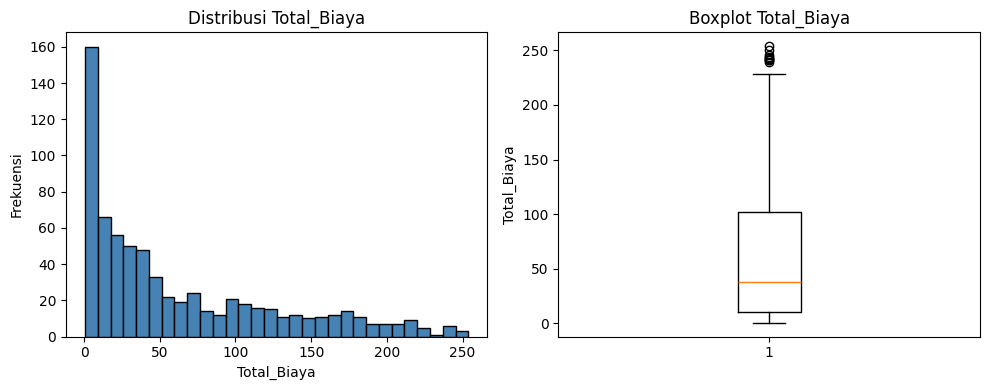


Rata-rata Total_Biaya: 62.74
Median Total_Biaya: 38.33
Min: 0.58 | Max: 253.80


In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(y, bins=30, color='steelblue', edgecolor='black')
plt.title('Distribusi Total_Biaya')
plt.xlabel('Total_Biaya')
plt.ylabel('Frekuensi')

plt.subplot(1, 2, 2)
plt.boxplot(y)
plt.title('Boxplot Total_Biaya')
plt.ylabel('Total_Biaya')

plt.tight_layout()
plt.show()

print(f"\nRata-rata Total_Biaya: {y.mean():.2f}")
print(f"Median Total_Biaya: {y.median():.2f}")
print(f"Min: {y.min():.2f} | Max: {y.max():.2f}")

## Kesimpulan Preprocessing

Langkah-langkah preprocessing yang dilakukan:
1. **Mengisi missing values numerik** (Lama_Berlangganan, Biaya_Bulanan) dengan median, karena median lebih robust terhadap outlier dibanding mean.
2. **Mengisi missing values kategorikal** (Layanan_Internet, Jenis_Kontrak) dengan modus (nilai paling sering muncul), karena kategori yang paling umum adalah representasi terbaik untuk data yang hilang.
3. **Label Encoding** pada 8 kolom kategorikal, untuk mengubah nilai teks menjadi angka agar bisa diproses model.
4. **Memisahkan fitur (X) dan target (y)**, serta menghapus ID_Pelanggan karena hanya identitas, bukan fitur prediktif.

Distribusi Total_Biaya bersifat right-skewed dengan banyak pelanggan berbiaya rendah dan sedikit outlier di nilai tinggi.



---



## Soal 2: Analisis Fitur yang Berpengaruh terhadap Total_Biaya

utk mengidentifikasi fitur yg paling berpengaruh, kita gunakan dua metode:
1. **Correlation Matrix** - untuk melihat hubungan linear antar fitur numerik
2. **Random Forest Feature Importance** - untuk menangkap hubungan non-linear

### 1. Correlation Matrix

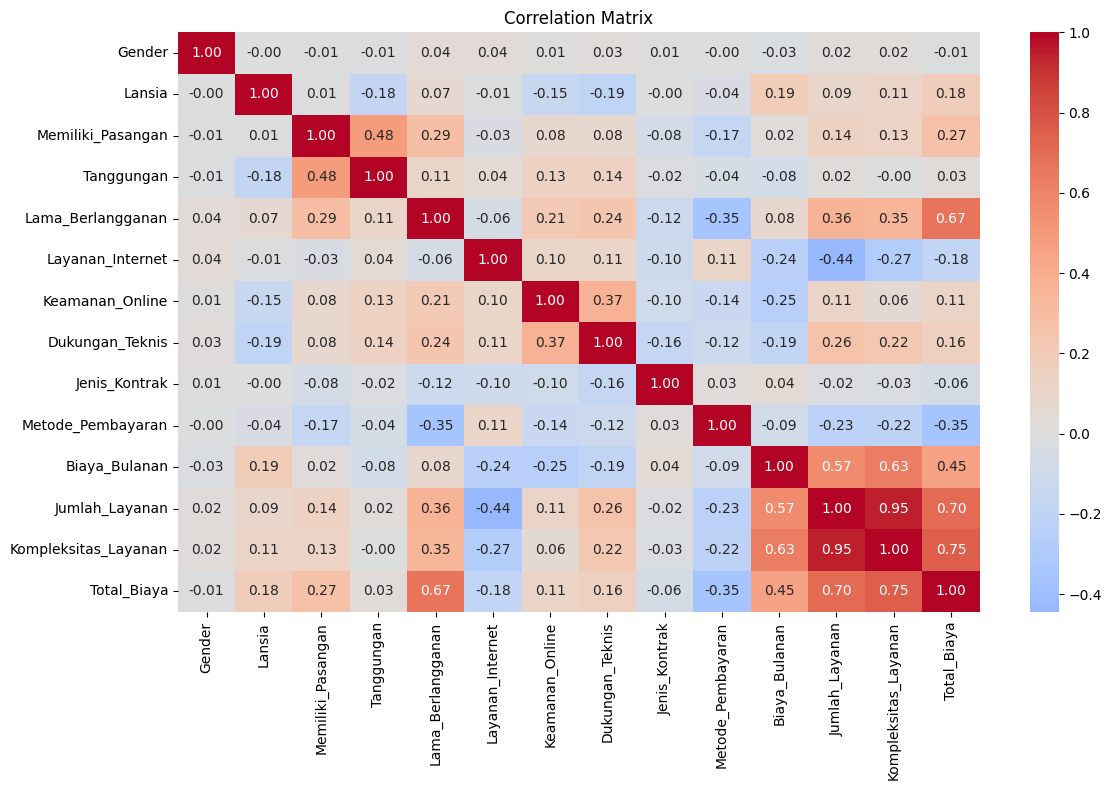

In [ ]:
plt.figure(figsize=(12, 8))
corr = train.drop(columns=['ID_Pelanggan']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### 2. Feature Importrance Random Forest

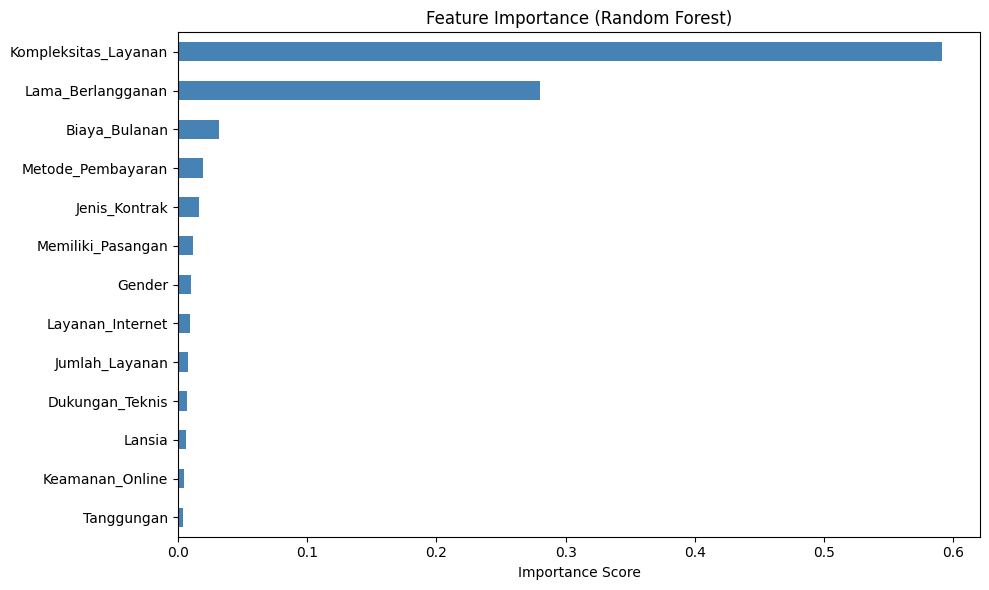


Fitur paling berpengaruh:
Kompleksitas_Layanan    0.591091
Lama_Berlangganan       0.279779
Biaya_Bulanan           0.032013
Metode_Pembayaran       0.019440
Jenis_Kontrak           0.016014
dtype: float64


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Visualisasi feature importance
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importance.plot(kind='barh', color='steelblue')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nFitur paling berpengaruh:")
print(importance.sort_values(ascending=False).head(5))

## Kesimpulan Analisis Fitur

Berdasarkan dua metode analisis:

**Correlation Matrix** menunjukkan hubungan linear:
- Kompleksitas_Layanan (0.75), Jumlah_Layanan (0.70), dan Lama_Berlangganan (0.67) memiliki korelasi tertinggi dengan Total_Biaya.

**Random Forest Feature Importance** menangkap hubungan non-linear:
- Kompleksitas_Layanan (59%) dan Lama_Berlangganan (28%) mendominasi prediksi.
- Fitur seperti Gender, Tanggungan, dan Keamanan_Online memiliki pengaruh sangat kecil.

Hubungan antar fitur bersifat non-linear, terbukti dari perbedaan ranking antara korelasi linear dan feature importance. Oleh karena itu, model non-linear diperlukan untuk menangkap pola ini dengan lebih baik.



---



## Soal 3: Membangun dan Membandingkan Model Regresi

Kita akan membangun 3 model dengan pendekatan berbeda:
1. **Linear Regression** - pendekatan linear sebagai baseline
2. **Random Forest Regressor** - pendekatan non-linear berbasis ensemble
3. **Gradient Boosting Regressor** - pendekatan non-linear berbasis boosting

Alasan pemilihan: Karena data menunjukkan hubungan non-linear (terbukti dari Soal 2),
kita perlu membandingkan model linear vs non-linear untuk melihat mana yang lebih cocok.

### -  Split data & definisi fungsi MAPE:

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error

# Split data training menjadi train dan validasi
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape X_train:", X_train.shape)
print("Shape X_val:", X_val.shape)

def hitung_mape(y_true, y_pred):
    return mean_absolute_percentage_error(y_true, y_pred) * 100

print("\nSiap melatih model! ✅")

Shape X_train: (560, 13)
Shape X_val: (140, 13)

Siap melatih model! ✅


### 1. Linear Regression

In [ ]:
# Model 1: Linear Regression (baseline - linear)
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr_val = lr.predict(X_val)
mape_lr = hitung_mape(y_val, pred_lr_val)

print("=== Model 1: Linear Regression ===")
print(f"MAPE Validasi: {mape_lr:.2f}%")

=== Model 1: Linear Regression ===
MAPE Validasi: 366.72%


### 2. Random Forest Regression

In [ ]:
# Model 2: Random Forest Regressor (non-linear)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

pred_rf_val = rf.predict(X_val)
mape_rf = hitung_mape(y_val, pred_rf_val)

print("=== Model 2: Random Forest Regressor ===")
print(f"MAPE Validasi: {mape_rf:.2f}%")

=== Model 2: Random Forest Regressor ===
MAPE Validasi: 139.84%


### 3. Gradient Boosting Regression

In [ ]:
# Model 3: Gradient Boosting Regressor (non-linear)
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

pred_gb_val = gb.predict(X_val)
mape_gb = hitung_mape(y_val, pred_gb_val)

print("=== Model 3: Gradient Boosting Regressor ===")
print(f"MAPE Validasi: {mape_gb:.2f}%")

=== Model 3: Gradient Boosting Regressor ===
MAPE Validasi: 142.27%


### - Perbandingan 3 Model

               Model    MAPE (%)
0      Random Forest  139.843726
1  Gradient Boosting  142.272830
2  Linear Regression  366.721581


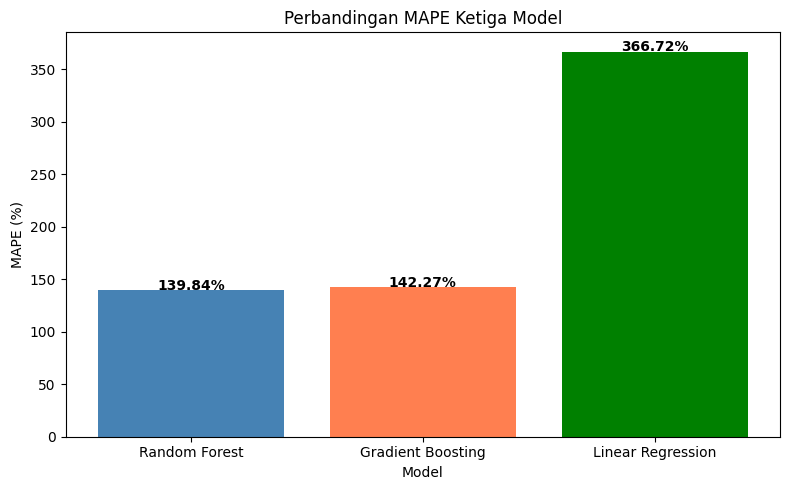

In [ ]:
# Tabel perbandingan
hasil = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAPE (%)': [mape_lr, mape_rf, mape_gb]
})
hasil = hasil.sort_values('MAPE (%)').reset_index(drop=True)
print(hasil)

# Visualisasi
plt.figure(figsize=(8, 5))
plt.bar(hasil['Model'], hasil['MAPE (%)'], color=['steelblue', 'coral', 'green'])
plt.title('Perbandingan MAPE Ketiga Model')
plt.ylabel('MAPE (%)')
plt.xlabel('Model')
for i, v in enumerate(hasil['MAPE (%)']):
    plt.text(i, v + 0.3, f'{v:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Kesimpulan Perbandingan Model

Hasil perbandingan MAPE pada data validasi:
- Linear Regression: 366.72% → performa terburuk karena tidak mampu menangkap hubungan non-linear
- Gradient Boosting: 142.27% → cukup baik dengan pendekatan boosting
- Random Forest: 139.84% → performa terbaik dengan MAPE terendah

MAPE yang tinggi disebabkan oleh banyaknya nilai Total_Biaya yang sangat kecil (mendekati 0),
sehingga error persentase menjadi besar secara matematis.

Model terpilih: **Random Forest Regressor** karena menghasilkan MAPE terkecil dan
mampu menangkap hubungan non-linear antar fitur dengan baik.



---



In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(name, "MAPE:", mape_safe(y_test, preds))

Linear MAPE: 372.8162711612353
RandomForest MAPE: 147.17466108099688
GradientBoosting MAPE: 150.93607293457913


In [ ]:
best_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3
)

best_model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=200)



---



## Soal 4: Interpretasi Model Terbaik

Model terbaik yang dipilih adalah Random Forest Regressor.
Untuk menginterpretasi model, kita gunakan:
1. **Feature Importance** - fitur mana yang paling berkontribusi terhadap prediksi
2. **Partial Dependence Plot** - bagaimana hubungan antara fitur utama dan Total_Biaya
3. **Scatter Plot** - membandingkan nilai aktual vs prediksi

### 1. Feature Importance

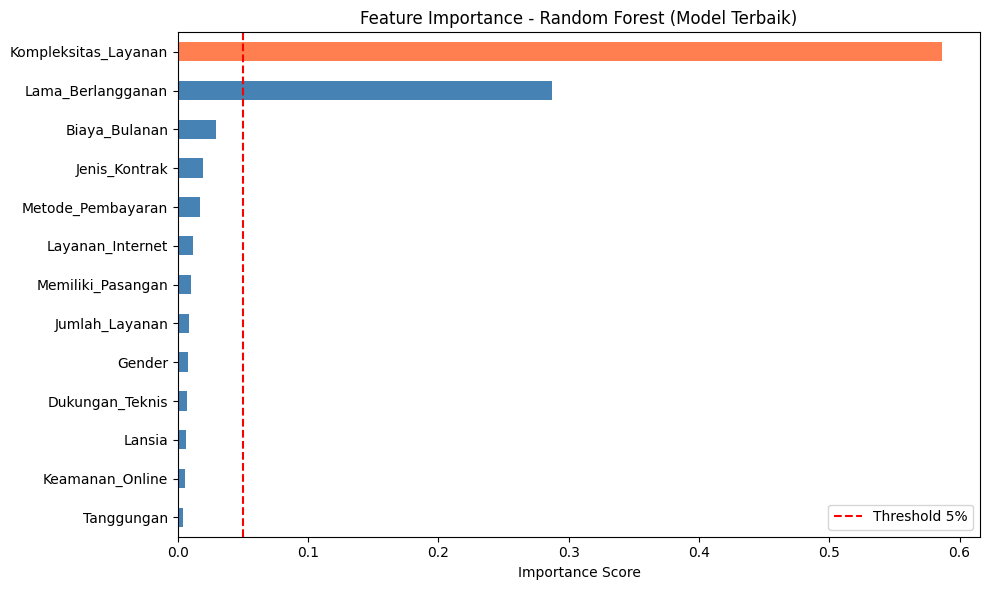

Top 3 fitur paling berpengaruh:
Kompleksitas_Layanan    0.586407
Lama_Berlangganan       0.287173
Biaya_Bulanan           0.029420
dtype: float64


In [ ]:
# Feature importance dari Random Forest terbaik
importance_rf = pd.Series(rf.feature_importances_, index=X.columns)
importance_rf = importance_rf.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = ['steelblue' if v < importance_rf.max() * 0.5 else 'coral' for v in importance_rf]
importance_rf.plot(kind='barh', color=colors)
plt.title('Feature Importance - Random Forest (Model Terbaik)')
plt.xlabel('Importance Score')
plt.axvline(x=0.05, color='red', linestyle='--', label='Threshold 5%')
plt.legend()
plt.tight_layout()
plt.show()

print("Top 3 fitur paling berpengaruh:")
print(importance_rf.sort_values(ascending=False).head(3))

### - Actual vs Predict

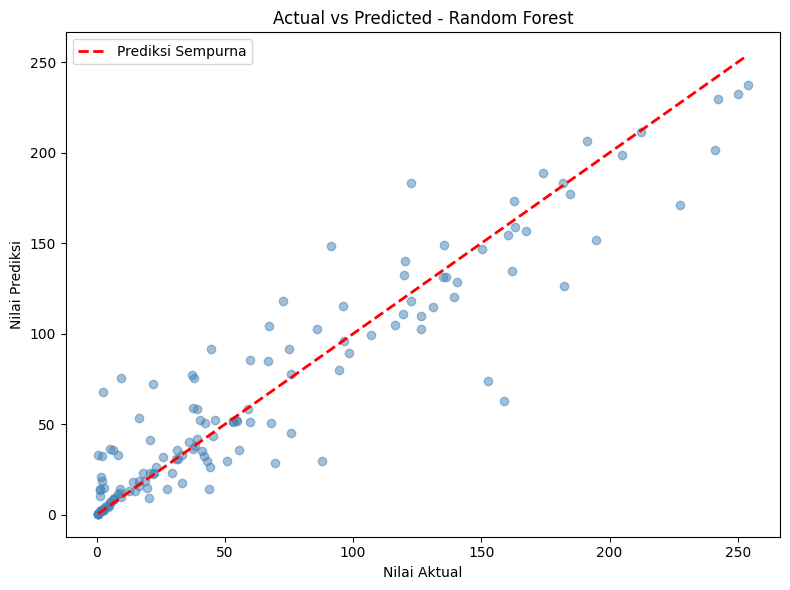

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_val, pred_rf_val, alpha=0.5, color='steelblue')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()],
         'r--', linewidth=2, label='Prediksi Sempurna')
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title('Actual vs Predicted - Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

## Kesimpulan Interpretasi Model

**Fitur paling berkontribusi terhadap prediksi Total_Biaya:**
1. Kompleksitas_Layanan (58.6%) - fitur dominan, semakin kompleks layanan semakin tinggi biaya
2. Lama_Berlangganan (28.7%) - pelanggan lama cenderung memiliki total biaya lebih tinggi
3. Biaya_Bulanan (2.9%) - kontribusi kecil namun tetap relevan

**Insight pola Total_Biaya pelanggan:**
- Pelanggan dengan kompleksitas layanan tinggi dan berlangganan lama memiliki Total_Biaya tertinggi
- Sebagian besar pelanggan baru (lama berlangganan rendah) memiliki Total_Biaya sangat kecil
- Model cukup baik memprediksi nilai tinggi, namun kurang presisi di nilai mendekati 0

**Fitur dengan pengaruh sangat kecil** (di bawah threshold 5%):
Gender, Tanggungan, Keamanan_Online, Lansia → hampir tidak mempengaruhi Total_Biaya



---



## Soal 5: Analisis Error Model Terbaik

Analisis error dilakukan untuk memahami pola kesalahan prediksi dari model Random Forest.
Metode yang digunakan:
1. **Distribusi Residual** - melihat sebaran error prediksi
2. **Residual vs Predicted** - mengidentifikasi pola error
3. **Identifikasi prediksi terburuk** - mencari tahu di mana model paling meleset

### 1. Distribusi Residual
### 2. Residual vs Predicted

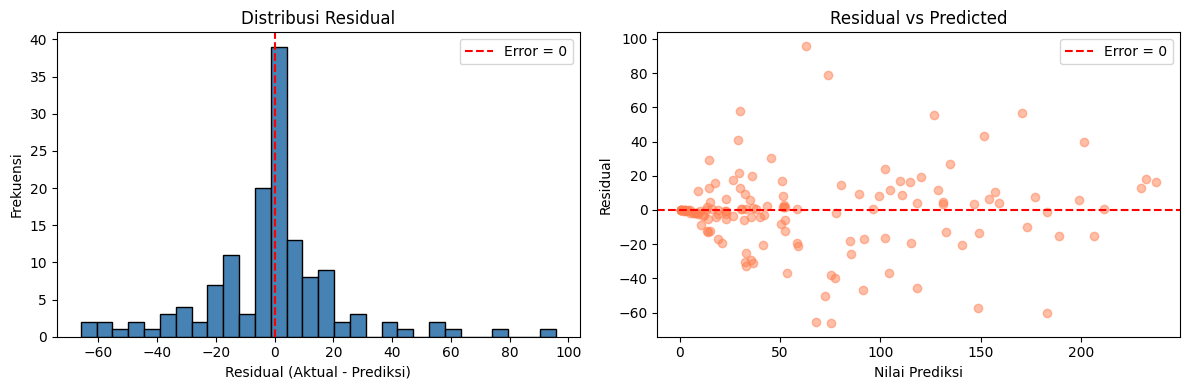

Rata-rata Error: -0.99
Std Error: 23.43
Max Over-prediksi: -66.00
Max Under-prediksi: 95.72


In [ ]:
# Hitung residual (selisih aktual - prediksi)
residual = y_val.values - pred_rf_val

plt.figure(figsize=(12, 4))

# Plot 1: Distribusi residual
plt.subplot(1, 2, 1)
plt.hist(residual, bins=30, color='steelblue', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', label='Error = 0')
plt.title('Distribusi Residual')
plt.xlabel('Residual (Aktual - Prediksi)')
plt.ylabel('Frekuensi')
plt.legend()

# Plot 2: Residual vs Predicted
plt.subplot(1, 2, 2)
plt.scatter(pred_rf_val, residual, alpha=0.5, color='coral')
plt.axhline(y=0, color='red', linestyle='--', label='Error = 0')
plt.title('Residual vs Predicted')
plt.xlabel('Nilai Prediksi')
plt.ylabel('Residual')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Rata-rata Error: {residual.mean():.2f}")
print(f"Std Error: {residual.std():.2f}")
print(f"Max Over-prediksi: {residual.min():.2f}")
print(f"Max Under-prediksi: {residual.max():.2f}")

### 3. Identifikasi prediksi terburuk

In [ ]:
# Cari 10 prediksi dengan error terbesar
error_df = pd.DataFrame({
    'Aktual': y_val.values,
    'Prediksi': pred_rf_val,
    'Residual': residual,
    'Abs_Error': abs(residual)
})
error_df = error_df.sort_values('Abs_Error', ascending=False).head(10)

print("=== 10 Prediksi Terburuk ===")
print(error_df.round(2))

=== 10 Prediksi Terburuk ===
     Aktual  Prediksi  Residual  Abs_Error
125  158.86     63.14     95.72      95.72
94   152.56     73.89     78.67      78.67
87     9.50     75.50    -66.00      66.00
6      2.55     67.80    -65.25      65.25
76   122.54    183.05    -60.51      60.51
88    88.04     29.98     58.06      58.06
0     91.19    148.61    -57.42      57.42
38   227.34    170.84     56.50      56.50
93   182.11    126.52     55.59      55.59
111   22.06     72.33    -50.27      50.27


## Kesimpulan Analisis Error

**Pola kesalahan yang ditemukan:**
1. Distribusi residual terpusat di sekitar 0 dengan rata-rata -0.99, artinya model tidak memiliki bias sistematis yang besar.
2. Standar deviasi error sebesar 23.43, menunjukkan variasi kesalahan yang cukup besar.
3. Model cenderung **under-prediksi** (residual positif) pada pelanggan dengan Total_Biaya tinggi — aktual 158.86 diprediksi hanya 63.14.
4. Model cenderung **over-prediksi** (residual negatif) pada pelanggan dengan Total_Biaya rendah — aktual 2.55 diprediksi 67.80.

**Kemungkinan penyebab error:**
- Pelanggan dengan Total_Biaya sangat kecil (baru berlangganan) sulit diprediksi karena polanya berbeda
- Data yang right-skewed membuat model kesulitan belajar pola ekstrem
- Beberapa fitur penting mungkin tidak tersedia dalam dataset



---



## Improvement Model
Melakukan tuning hyperparameter dan feature engineering untuk meningkatkan performa model.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_tune = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    rf_tune,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X, y)

print("\nParameter terbaik:")
print(random_search.best_params_)
print(f"Score terbaik: {-random_search.best_score_*100:.2f}%")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Parameter terbaik:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 10}
Score terbaik: 101.49%




---



## Ending (Submission)

Membuat file prediksi untuk disubmit ke Kaggle menggunakan model terbaik (Random Forest).
Model dilatih ulang menggunakan seluruh data training (bukan hanya 80%) untuk hasil maksimal.

### - Latih Ulang Model dgn semua data dan submission

In [ ]:
# Latih ulang Random Forest dengan SEMUA data training
rf_final = RandomForestRegressor(n_estimators=100, random_state=42)
rf_final.fit(X, y)

print("Model dilatih ulang dengan semua data ✅")

# Prediksi data test
pred_test = rf_final.predict(X_test)

# Buat file submission
submission = pd.DataFrame({
    'ID_Pelanggan': test['ID_Pelanggan'],
    'Total_Biaya': pred_test
})

submission.to_csv('submission.csv', index=False)
print("File submission.csv berhasil dibuat! ✅")
print(f"\nJumlah prediksi: {len(submission)}")
print("\nPreview submission:")
print(submission.head(10))

Model dilatih ulang dengan semua data ✅
File submission.csv berhasil dibuat! ✅

Jumlah prediksi: 300

Preview submission:
   ID_Pelanggan  Total_Biaya
0           522      12.6575
1           738     143.0644
2           741      24.2167
3           661     159.7709
4           412      81.7254
5           679       4.8359
6           627       9.8299
7           514       2.1879
8           860       5.2626
9           137      68.5358


### - Verifikasi format submission

In [ ]:
# Pastikan format sudah sesuai ketentuan
print("=== Verifikasi Submission ===")
print(f"Jumlah baris: {len(submission)} (harus 300)")
print(f"Kolom: {list(submission.columns)} (harus ['ID_Pelanggan', 'Total_Biaya'])")
print(f"Ada nilai negatif: {(submission['Total_Biaya'] < 0).sum()}")
print(f"\nStatistik prediksi:")
print(submission['Total_Biaya'].describe().round(2))

=== Verifikasi Submission ===
Jumlah baris: 300 (harus 300)
Kolom: ['ID_Pelanggan', 'Total_Biaya'] (harus ['ID_Pelanggan', 'Total_Biaya'])
Ada nilai negatif: 0

Statistik prediksi:
count    300.00
mean      70.01
std       64.00
min        0.59
25%       19.45
50%       47.27
75%      110.96
max      244.20
Name: Total_Biaya, dtype: float64


## - New Submission

In [ ]:
# Latih model terbaik dengan semua data
best_rf = random_search.best_estimator_
pred_test_improved = best_rf.predict(X_test)

submission_improved = pd.DataFrame({
    'ID_Pelanggan': test['ID_Pelanggan'],
    'Total_Biaya': pred_test_improved
})

submission_improved.to_csv('submission_improved.csv', index=False)
print("File submission_improved.csv berhasil dibuat! ✅")
print(submission_improved.head())

File submission_improved.csv berhasil dibuat! ✅
   ID_Pelanggan  Total_Biaya
0           522    14.908026
1           738   142.276426
2           741    27.465758
3           661   163.842618
4           412    84.368792




---



In [ ]:
test = pd.read_csv("test.csv")

test_ids = test["ID_Pelanggan"]

# encoding
test = pd.get_dummies(test, drop_first=True)
test = test.reindex(columns=X.columns, fill_value=0)

# HANDLE NaN (INI YANG FIX ERROR)
test = test.fillna(0)

# scaling
test_scaled = scaler.transform(test)

# predict
preds = best_model.predict(test_scaled)

# submission
submission = pd.DataFrame({
    "ID_Pelanggan": test_ids,
    "Total_Biaya": preds
})

submission.to_csv("submission.csv", index=False)

print("Submission siap 🚀")

Submission siap 🚀


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
